In [7]:
import pandas as pd
import numpy as np



df = pd.read_csv('world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy',' Freedom', 'Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head()) 

Dataset: 63 countries, 9 columns
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy   Freedom  Generosity  Corruption  
0           0.954             71.9     0.949       0.142       0.179  
1           0.954             72.7     0.931       0.168       0.234  
2           0.983             72.5     0.961       0.260       0.150  
3           0.916             72.4     0.903       0.149       0.826  
4           0.939             72.4     0.879       0.240       0.296  


In [8]:
import plotly.express as px
import plotly.graph_objects as go


print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])

Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 – 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia            4.036
50        Kenya            Sub-Saharan Africa            4.112
54       Uganda

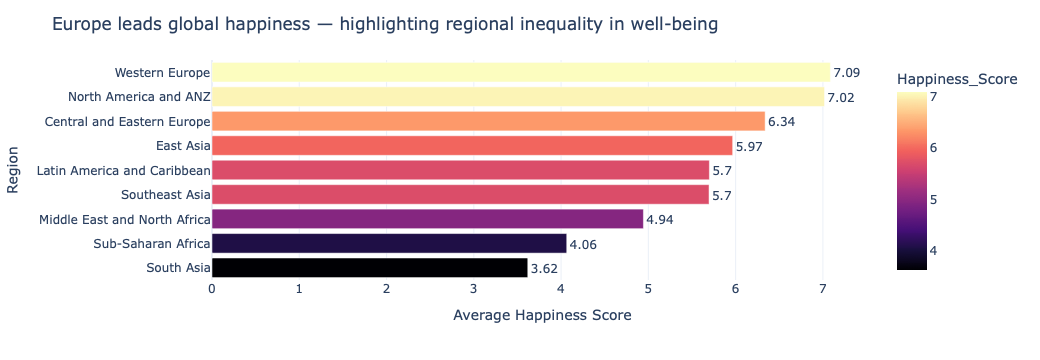

In [26]:
import plotly.express as px


region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score'))

fig = px.bar(
    region_avg,
    x='Happiness_Score',
    y='Region',
    orientation='h',
    text=region_avg['Happiness_Score'].round(2),
    color='Happiness_Score',
    color_continuous_scale='magma'
)


fig.update_layout(
    title="Europe leads global happiness — highlighting regional inequality in well-being",
    xaxis_title="Average Happiness Score",
    yaxis_title="Region",
    xaxis=dict(range=[0, region_avg['Happiness_Score'].max() + 0.5]),
    template="plotly_white"
)


fig.update_yaxes(categoryorder='total ascending')


fig.update_traces(textposition='outside', cliponaxis=False)



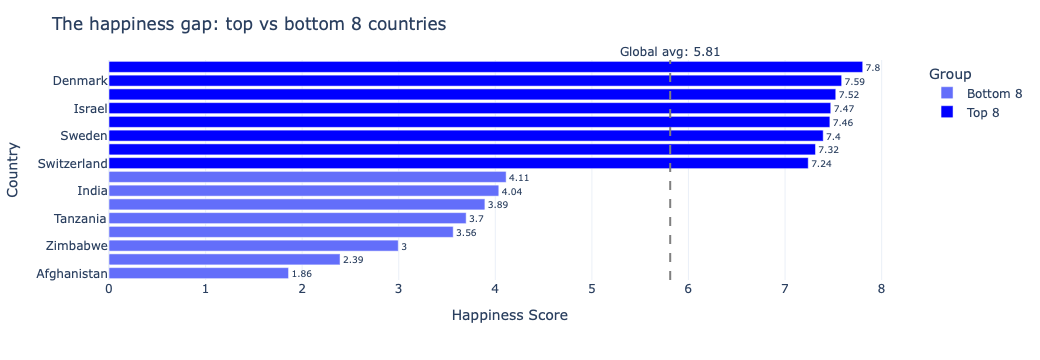

In [28]:
import plotly.express as px
import pandas as pd

top8 = df.nlargest(8, 'Happiness_Score')[['Country', 'Happiness_Score']].copy()
top8['Group'] = 'Top 8'

bottom8 = df.nsmallest(8, 'Happiness_Score')[['Country', 'Happiness_Score']].copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8])  # bottom first so top renders at top
global_avg = df['Happiness_Score'].mean()

fig = px.bar(
    combined,
    x='Happiness_Score',
    y='Country',
    orientation='h',
    color='Group',
    text=combined['Happiness_Score'].round(2),
    color_discrete_map={
        'Top 8': 'blue',
        'Bottom 8': 'light green'
    }
)

fig.add_vline(
    x=global_avg,
    line_dash="dash",
    line_color="gray",
    annotation_text=f"Global avg: {global_avg:.2f}",
    annotation_position="top"
)

fig.update_layout(
    title="The happiness gap: top vs bottom 8 countries",
    xaxis_title="Happiness Score",
    yaxis_title="Country",
    xaxis=dict(range=[0, combined['Happiness_Score'].max() + 0.5]),
    template="plotly_white"
)

fig.update_yaxes(categoryorder='total ascending')
fig.update_traces(textposition='outside', cliponaxis=False)

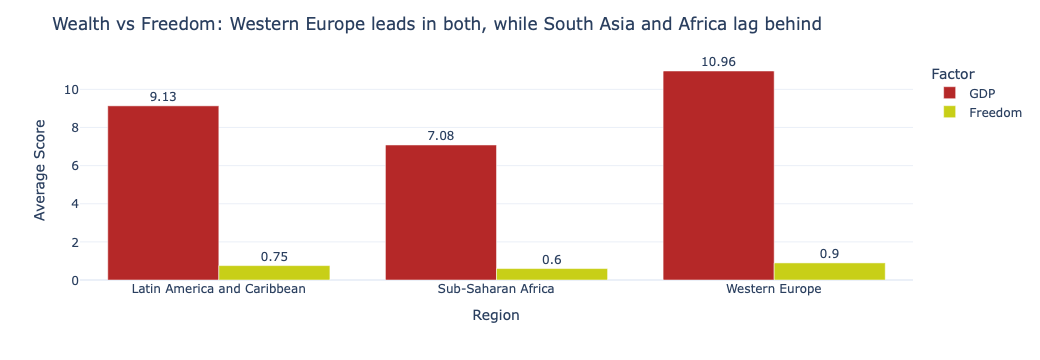

In [5]:
import pandas as pd
import plotly.express as px

df.columns = df.columns.str.strip()
regions = [
    'Western Europe',
    'Latin America and Caribbean',
    'Eastern Asia',
    'Sub-Saharan Africa',
    'Southern Asia'
]
filtered = df[df['Region'].isin(regions)]
agg = (filtered.groupby('Region')[['GDP', 'Freedom']]
       .mean()
       .reset_index())
melted = agg.melt(
    id_vars='Region',
    value_vars=['GDP', 'Freedom'],
    var_name='Factor',
    value_name='Value'
)


fig = px.bar(
    melted,
    x='Region',
    y='Value',
    color='Factor',
    barmode='group',
    text=melted['Value'].round(2),
    color_discrete_map={
        'GDP': '#b52828',
        'Freedom': '#c8cf17'
    }
)

fig.update_layout(
    title="Wealth vs Freedom: Western Europe leads in both, while South Asia and Africa lag behind",
    xaxis_title="Region",
    yaxis_title="Average Score",
    template="plotly_white"
)
fig.update_traces(textposition='outside', cliponaxis=False)